# Análise Risco de Crédito

## Introdução - Risco de Crédito

O risco de crédito é um dos principais desafios enfrentados por instituições financeiras, especialmente bancos digitais que operam com grande volume de clientes e decisões automatizadas. Conceder crédito envolve equilibrar dois objetivos estratégicos: ampliar o acesso ao crédito e, ao mesmo tempo, controlar o risco de inadimplência.

Neste projeto, será realizada uma análise exploratória e estratégica utilizando o dataset Default of Credit Card Clients, disponibilizado pelo UCI Machine Learning Repository. O **objetivo** é simular o papel de um Analista de Risk Platforms, avaliando regras de concessão de crédito e seus impactos operacionais.

A análise busca demonstrar, de forma prática, como dados históricos podem ser utilizados para apoiar decisões mais seguras e estratégicas na área de risco.

## Contexto de Negócio

Conceder crédito envolve um equilíbrio entre crescimento e segurança financeira.

Se uma instituição aprovar muitos clientes, pode aumentar sua receita e ampliar sua base, mas também pode elevar o número de clientes inadimplentes. Por outro lado, se for excessivamente rigorosa nas aprovações, pode reduzir perdas, mas limitar seu crescimento.

*Esse desafio pode ser comparado a um porteiro de um prédio:*

se ele deixar todos entrarem, o prédio pode ter problemas; se não deixar quase ninguém entrar, o prédio fica vazio.

No contexto deste projeto, será simulada a avaliação de algumas regras de crédito utilizando dados históricos de clientes como por exemplo:
- A taxa de aprovação de clientes
- A taxa de inadimplência
- O impacto potencial de ajustes na política de crédito

Dessa forma, o projeto busca desenvolver um raciocínio estruturado sobre como regras de risco podem ser avaliadas e monitoradas de maneira orientada por dados.

## Objetivo



Dado o contexto, a equipe de negócio passou a seguinte hipótese a ser respondida:
- **Clientes com histórico de atraso superior a 2 meses apresentam risco significativamente maior de inadimplência?**

## Dicionário de dados

| #  | Variável                   | Tipo             | Descrição                                    | Valores / Observações                                                                       |
| -- | -------------------------- | ---------------- | -------------------------------------------- | ------------------------------------------------------------------------------------------- |
| 0  | ID                         | Numérico         | Identificador único do cliente               | Apenas identificador, não usar para modelagem                                               |
| 1  | LIMIT_BAL                  | Numérico         | Limite total de crédito concedido ao cliente | Em dólares taiwaneses (NT$)                                                                 |
| 2  | SEX                        | Numérico         | Sexo do cliente                              | 1 = Masculino, 2 = Feminino                                                                 |
| 3  | EDUCATION                  | Numérico         | Nível educacional                            | 1 = Pós-graduação, 2 = Universidade, 3 = Ensino médio, 4 = Outros, 0/5/6 = Não especificado |
| 4  | MARRIAGE                   | Numérico         | Estado civil                                 | 1 = Casado, 2 = Solteiro, 3 = Outros                                                        |
| 5  | AGE                        | Numérico         | Idade do cliente                             | Em anos                                                                                     |
| 6  | PAY_0                      | Numérico         | Status de pagamento em setembro              | -2 = Sem consumo, -1 = Pagou em dia, 0 = Sem atraso, 1-8 = Meses de atraso                  |
| 7  | PAY_2                      | Numérico         | Status de pagamento em agosto                | Mesmo padrão do PAY_0                                                                       |
| 8  | PAY_3                      | Numérico         | Status de pagamento em julho                 | Mesmo padrão do PAY_0                                                                       |
| 9  | PAY_4                      | Numérico         | Status de pagamento em junho                 | Mesmo padrão do PAY_0                                                                       |
| 10 | PAY_5                      | Numérico         | Status de pagamento em maio                  | Mesmo padrão do PAY_0                                                                       |
| 11 | PAY_6                      | Numérico         | Status de pagamento em abril                 | Mesmo padrão do PAY_0                                                                       |
| 12 | BILL_AMT1                  | Numérico         | Valor da fatura em setembro                  | Em NT$                                                                                      |
| 13 | BILL_AMT2                  | Numérico         | Valor da fatura em agosto                    | Em NT$                                                                                      |
| 14 | BILL_AMT3                  | Numérico         | Valor da fatura em julho                     | Em NT$                                                                                      |
| 15 | BILL_AMT4                  | Numérico         | Valor da fatura em junho                     | Em NT$                                                                                      |
| 16 | BILL_AMT5                  | Numérico         | Valor da fatura em maio                      | Em NT$                                                                                      |
| 17 | BILL_AMT6                  | Numérico         | Valor da fatura em abril                     | Em NT$                                                                                      |
| 18 | PAY_AMT1                   | Numérico         | Valor pago em setembro                       | Em NT$                                                                                      |
| 19 | PAY_AMT2                   | Numérico         | Valor pago em agosto                         | Em NT$                                                                                      |
| 20 | PAY_AMT3                   | Numérico         | Valor pago em julho                          | Em NT$                                                                                      |
| 21 | PAY_AMT4                   | Numérico         | Valor pago em junho                          | Em NT$                                                                                      |
| 22 | PAY_AMT5                   | Numérico         | Valor pago em maio                           | Em NT$                                                                                      |
| 23 | PAY_AMT6                   | Numérico         | Valor pago em abril                          | Em NT$                                                                                      |
| 24 | default payment next month | Binária (Target) | Indica inadimplência no mês seguinte         | 1 = Default, 0 = Não Default                                                                |


## Importando as Bibliotecas e os Dados

In [127]:
# Bibliotecas

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Visualizando os dados para conhecê-los, decidi alterar o nome das colunas para a primeira linha do cabeçalho onde eu posso facilitar a leitura das colunas, portanto, usarei o parâmetro **header=1**

In [128]:
df = pd.read_csv('data/default-of-credit-card-clients.csv', header=1)

In [129]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [130]:
# Tamanho do conjuntos de dados

print(f"O número de linhas é: {df.shape[0]} linhas.")
print(f"O total de colunas é: {df.shape[1]} colunas.")

O número de linhas é: 30000 linhas.
O total de colunas é: 25 colunas.


In [131]:
# Nome das colunas

df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [132]:
# Tipo das variáveis dos dados

df.dtypes

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

- Todas as colunas são do tipo int(inteiro), conforme relatado na descrição das variáveis.
- Também foi instruído que o conjunto de dados não possui dados nulos, entretanto, para praticar e para ter absoluta certeza, irei checar logo abaixo.

**Observação**
- A variável ID irá permanecer e por enquanto não será modificada no conjunto de dados.

In [133]:
# Distribuição de nulos por variável(coluna)

(df.isnull().sum()/df.shape[0] * 100).round(2) #round() neste caso será utilizado para deixar mais "claro" a visualização percentual.

ID                            0.0
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default payment next month    0.0
dtype: float64

Confirmado o dados não possuem *nulos*, portanto, não será necessário entendimento e tratamento sobre.

## (EDA) Análise Univariada

O objetivo desta análise é compreender a distribuição dos dados e alguns comportamentos dos mesmos e ter insights sobre as variáveis(colunas) do conjunto de dados.

### Variáveis Categóricas

Por ter "categorias" optei por considerar as variáveis "SEX"; "EDUCATION" e "MARITAL_STATUS" como categóricas neste contexto.

#### SEX (Gênero)

Conforme o dicionário de dados acima:
- 1 = masculino
- 2 = feminino

In [134]:
# Frequência Absoluta E Percentual
freq_absoluta = df['SEX'].value_counts()
freq_percentual = df['SEX'].value_counts(normalize=True) * 100

# Criando DataFrame com resultados
tabela_frequencia = pd.DataFrame({
    'Frequência Absoluta': freq_absoluta,
    'Frequência Percentual (%)': freq_percentual.round(2)
}).sort_index()

print("TABELA DE FREQUÊNCIA VARIÁVEL SEX(Gênero):")
print("=" * 50)
print(tabela_frequencia)

TABELA DE FREQUÊNCIA VARIÁVEL SEX(Gênero):
     Frequência Absoluta  Frequência Percentual (%)
SEX                                                
1                  11888                      39.63
2                  18112                      60.37


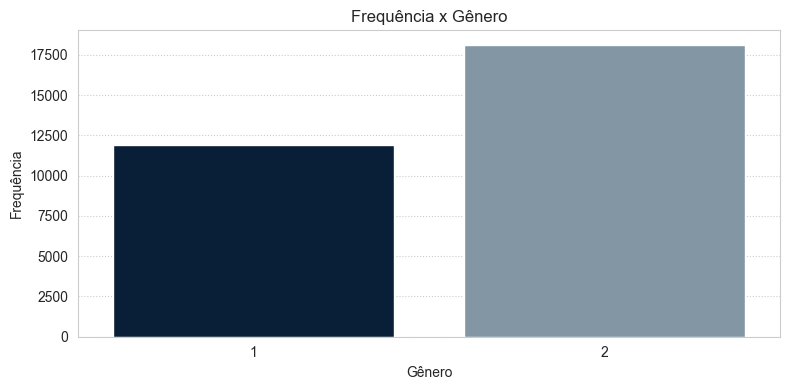

In [135]:
fig, ax = plt.subplots(figsize = (8,4))
sns.set_style("whitegrid", {"grid.linestyle": ":"})
# Definindo a paleta de cores
colors = ["#001F3F", "#7D99A8"]
sns.set_palette(sns.color_palette(colors))
sns.countplot(x='SEX', data=df, hue='SEX', palette=colors, legend=False)
ax.set_xlabel("Gênero")
ax.set_ylabel("Frequência")
ax.set_title("Frequência x Gênero")
plt.tight_layout()

A quantidade de mulheres no conjunto de dados é **superior** aos homens com porcentual de **60,37%** para mulheres contra 39.63% de homens.

#### EDUCATION

In [136]:
df.EDUCATION.unique()

array([2, 1, 3, 5, 4, 6, 0])

Conforme o dicionário acima:

1 = Pós-graduação, 2 = Universidade, 3 = Ensino médio, 4 = Outros, 0/5/6 = Não especificado

In [137]:
# Frequência Absoluta E Percentual
freq_absoluta = df['EDUCATION'].value_counts()
freq_percentual = df['EDUCATION'].value_counts(normalize=True) * 100

# Criando DataFrame com resultados
tabela_frequencia = pd.DataFrame({
    'Frequência Absoluta': freq_absoluta,
    'Frequência Percentual (%)': freq_percentual.round(2)
}).sort_index()

print("TABELA DE FREQUÊNCIA VARIÁVEL EDUCATION(Educação):")
print("=" * 58)
print(tabela_frequencia)

TABELA DE FREQUÊNCIA VARIÁVEL EDUCATION(Educação):
           Frequência Absoluta  Frequência Percentual (%)
EDUCATION                                                
0                           14                       0.05
1                        10585                      35.28
2                        14030                      46.77
3                         4917                      16.39
4                          123                       0.41
5                          280                       0.93
6                           51                       0.17


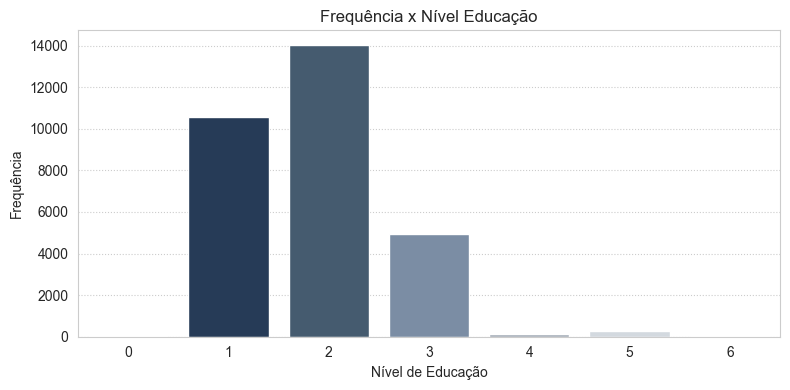

In [138]:
fig, ax = plt.subplots(figsize = (8,4))
# Definindo a paleta de cores
# Paleta expandida com 7 cores
colors = ["#001F3F",  "#1E3A5F",  "#3E5C76",  "#748CAB",  "#A2ADBB",  "#D1D9E1", "#ECEFF1"]
sns.set_palette(sns.color_palette(colors))
sns.countplot(x='EDUCATION', data=df, hue='EDUCATION', palette=colors, legend=False)
ax.set_xlabel("Nível de Educação")
ax.set_ylabel("Frequência")
ax.set_title("Frequência x Nível Educação")
plt.tight_layout()

O top 3 frequência de risco por Educação consiste em:
- **Universidade (2)** = 14030 clientes (46,77%)
- **Pós-graduação (1)** = 10585 clientes (35.28%)
- **Ensino médio (3)** = 4917 clientes (16,39%)
- **Outros e Não especificado (0,4,5,6)** = 468 clientes (1,56%)

#### MARITAL_STATUS

Relembrando:

1 = Casado, 2 = Solteiro, 3 = Outros

Conforme o dicionário de dados, optei por alterar o nome da coluna "Marriage" para "Marital_Status", pois, faz mais sentido para os dados presentes na coluna.

In [139]:
df = df.rename(columns={'MARRIAGE': 'MARITAL_STATUS'})
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARITAL_STATUS,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [140]:
# Frequência Absoluta E Percentual
freq_absoluta = df['MARITAL_STATUS'].value_counts()
freq_percentual = df['MARITAL_STATUS'].value_counts(normalize=True) * 100

# Criando DataFrame com resultados
tabela_frequencia = pd.DataFrame({
    'Frequência Absoluta': freq_absoluta,
    'Frequência Percentual (%)': freq_percentual.round(2)
}).sort_index()

print("TABELA DE FREQUÊNCIA VARIÁVEL MARITAL_STATUS:")
print("=" * 58)
print(tabela_frequencia)

TABELA DE FREQUÊNCIA VARIÁVEL MARITAL_STATUS:
                Frequência Absoluta  Frequência Percentual (%)
MARITAL_STATUS                                                
0                                54                       0.18
1                             13659                      45.53
2                             15964                      53.21
3                               323                       1.08


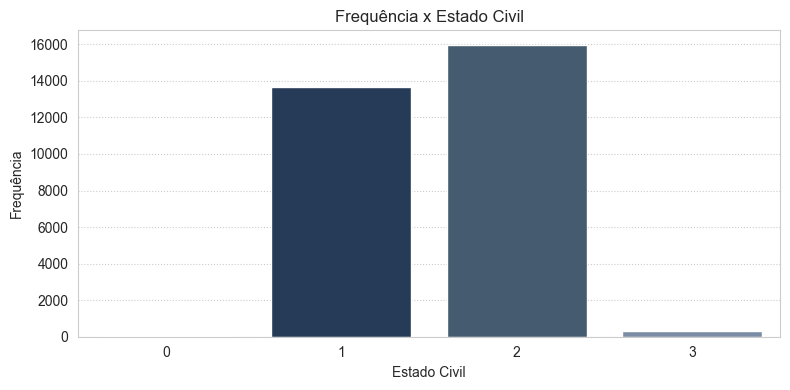

In [141]:
fig, ax = plt.subplots(figsize = (8,4))
# Definindo a paleta de cores
# Paleta expandida com 7 cores
colors = ["#001F3F",  "#1E3A5F",  "#3E5C76",  "#748CAB"]
sns.set_palette(sns.color_palette(colors))
sns.countplot(x='MARITAL_STATUS', data=df, hue='MARITAL_STATUS', palette=colors, legend=False)
ax.set_xlabel("Estado Civil")
ax.set_ylabel("Frequência")
ax.set_title("Frequência x Estado Civil")
plt.tight_layout()

De acordo com a frequência, observamos que o conjunto de dados apresenta um público Solteiro superior a Casados e outros.

- **Solteiro (2)**: 15964(53,21%)
- **Casado (1)**: 13659(45.53%)
- **Outros (0 e 3)**: 377(1.26%) 

### Variáveis Numéricas

In [142]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARITAL_STATUS,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


#### AGE

In [143]:
print("ANÁLISE DA COLUNA: AGE")
print("=" * 50)

# Visualizando as estatísticas
# Neste caso como é uma variável numérica usaremos o .descibre() para obter as eststísticas que precisamos.
print("ESTATÍSTICAS DESCRITIVAS:")
stats = df['AGE'].describe()
print(stats)


ANÁLISE DA COLUNA: AGE
ESTATÍSTICAS DESCRITIVAS:
count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64


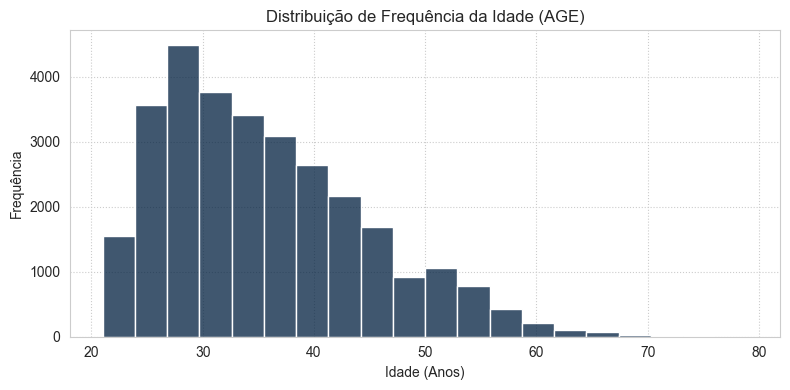

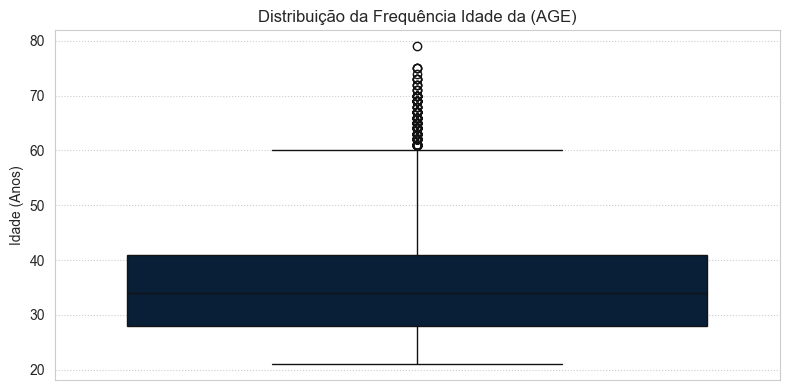

In [144]:
# Histograma
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#001F3F"]
sns.histplot(df['AGE'], bins=20, color=colors[0])
ax.set_xlabel("Idade (Anos)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de Frequência da Idade (AGE)")
plt.tight_layout()

# Boxplot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#001F3F"]
sns.boxplot(y=df['AGE'], color=colors[0])
ax.set_ylabel("Idade (Anos)")
ax.set_title("Distribuição da Frequência Idade da (AGE)")
plt.tight_layout()

Analisando as visualizações e pelo intervalos interquatis, percebemos que os clientes do conjunto de dados se concentram entre 21 a 41 anos de idade, um público relativamente mais novo, dado que grande parte são estudantes e muitos(as) são solteiros.

Sobre o boxplot também notamos uma assimetria positiva, indicando que os valores "atípicos" neste caso são relevantes, por se tratar de crédito bancário, temos clientes que estão na base de dados que tem uma faixa de idade superior, porém, não em maioria, conforme mostrando no boxplot e nas estatistísticas acima.

#### Pay_0 a Pay_6 (**status do pagamento**)

De acordo com o dicionário de dados:

PAY_0 a 6 representa o status de pagamento.

-2 = Sem consumo, -1 = Pagou em dia, 0 = Sem atraso, 1-8 = Meses de atraso

Meses:

- PAY_0 = Setembro

- PAY_2 = Agosto

- PAY_3 = Julho

- PAY_4 = Junho

- PAY_5 = Maio

- PAY_6 = Abril

In [145]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARITAL_STATUS', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [146]:
# Lista com as colunas de histórico de pagamento
colunas_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

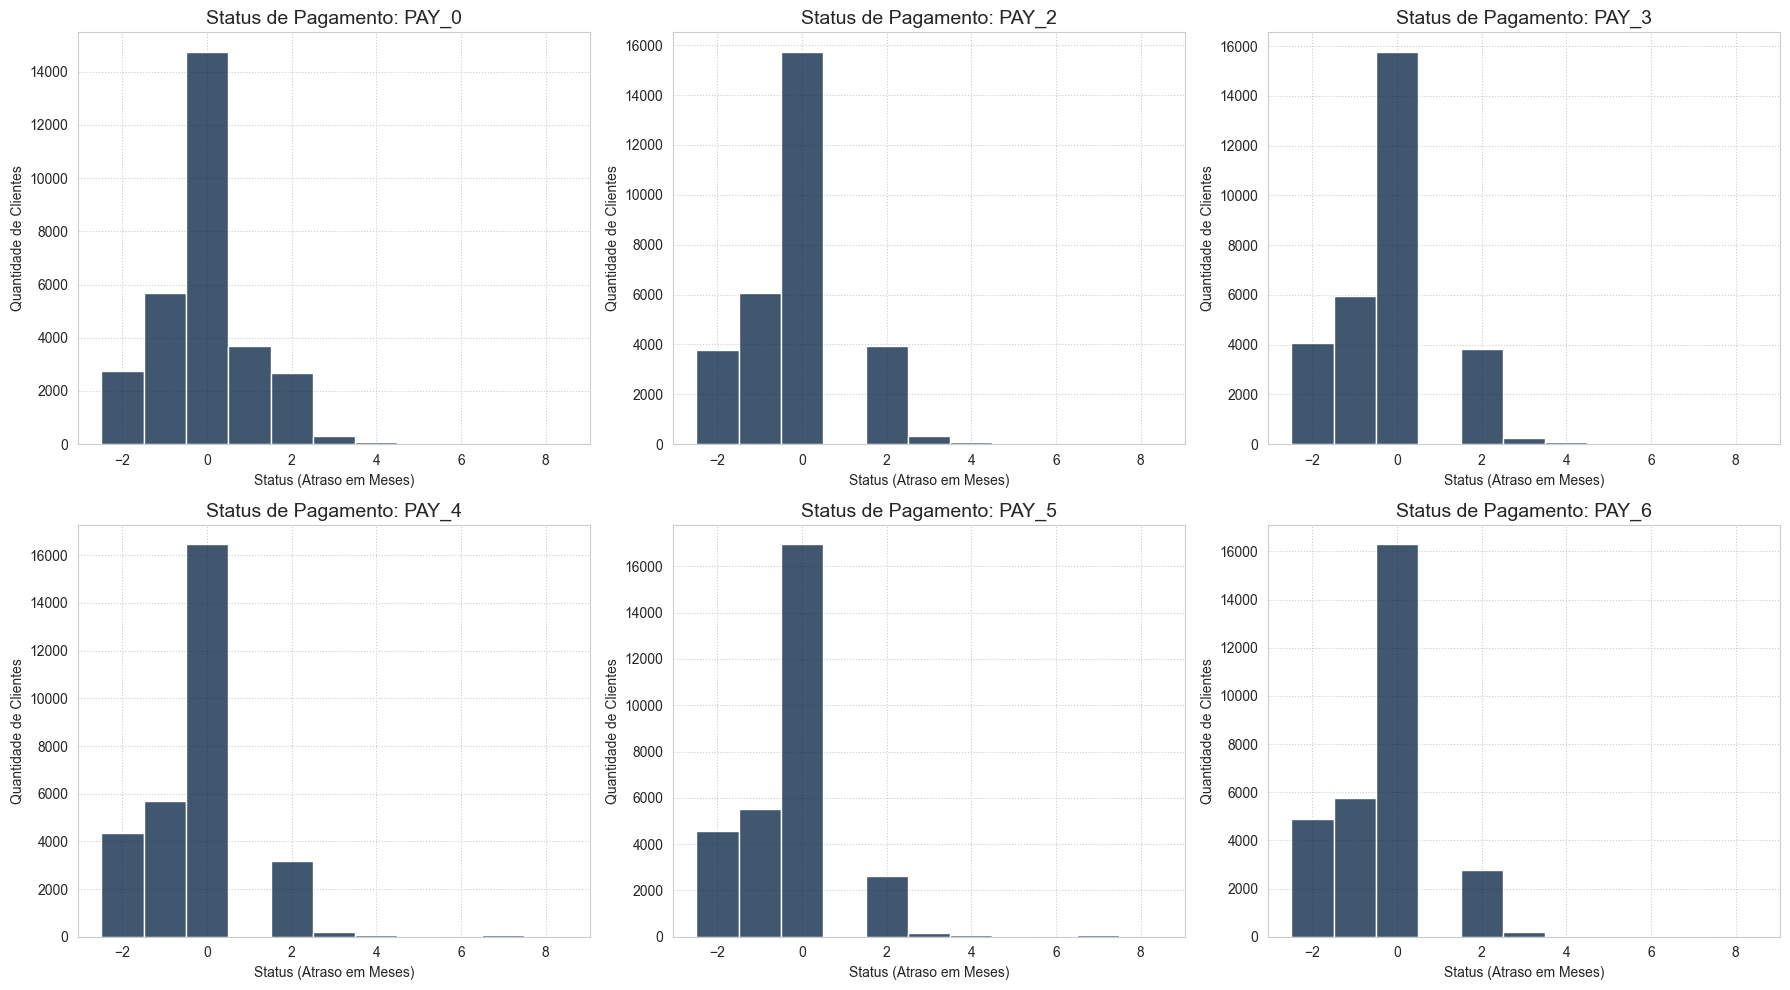

In [147]:
# Configurações visuais
colors = ["#001F3F"]

# Criando a grade (2 linhas x 3 colunas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Loop for para gerar os histogramas
for i, col in enumerate(colunas_pay):
    row = i // 3
    col_idx = i % 3
    
    # Criando o gráfico
    # discrete=True é ótimo aqui porque os valores são categorias numéricas (-1, 0, 1...)
    sns.histplot(df[col], color=colors[0], discrete=True, ax=axes[row, col_idx])
    
    # Customização de cada subgráfico
    axes[row, col_idx].set_title(f'Status de Pagamento: {col}', fontsize=14)
    axes[row, col_idx].set_xlabel('Status (Atraso em Meses)')
    axes[row, col_idx].set_ylabel('Quantidade de Clientes')

# Ajuste final de layout
plt.tight_layout()

Observando os histogramas percebe-se que houve um aumento de atraso de pagamento no semestre, isto é, de Abril(PAY_6) a Setembro(PAY_0), então a tendência de inadimplência tem evoluido (preocupante). Para visualizarmos em taxas percentuais de aumento, irei criar uma tabela com os valores.

In [148]:
# Dicionário para armazenar os resultados
taxas_inadimplencia = {}

for col in colunas_pay:
    # Calculando a proporção de clientes com valor > 0 (atraso)
    total_clientes = len(df[col])
    inadimplentes = len(df[df[col] > 0])
    taxa = (inadimplentes / total_clientes) * 100
    taxas_inadimplencia[col] = round(taxa, 2)

# Transformando em um DataFrame para facilitar a visualização
df_evolucao = pd.DataFrame(list(taxas_inadimplencia.items()), columns=['Mês', 'Taxa de Inadimplência (%)'])
print(df_evolucao.sort_values(by='Mês', ascending=False)) # Mostra do mais antigo para o mais novo

     Mês  Taxa de Inadimplência (%)
5  PAY_6                      10.26
4  PAY_5                       9.89
3  PAY_4                      11.70
2  PAY_3                      14.04
1  PAY_2                      14.79
0  PAY_0                      22.73


Conforme a tabela acima, temos de fato, uma **crescente de atraso** do pagamento do cartão, um exemplo de comparação do mês de Abril(PAY_6) para Setembro(PAY_0) foi um **aumento** de **12,47%** uma porcentagem bem expressiva e preocupante.

#### BILL_AMT1 a BILL_AMT6 (**valor da fatura**)

Refrescando a memória no dicionário de dados:

BILL_AMT: refere-se ao valor da fatura dos clientes.

- BILL_AMT1 = Valor da Fatura de Setembro

- BILL_AMT2 = Valor da Fatura de Agosto

- BILL_AMT3 = Valor da Fatura de Julho

- BILL_AMT4 = Valor da Fatura de Junho

- BILL_AMT5 = Valor da Fatura de Maio

- BILL_AMT6 = Valor da Fatura de Abril

In [149]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARITAL_STATUS', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [150]:
# Lista de valores da faturas dos meses
colunas_bill_amt = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Estatísticas descritivas para as colunas de fatura
estatisticas_bill = df[colunas_bill_amt].describe()
estatisticas_bill

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


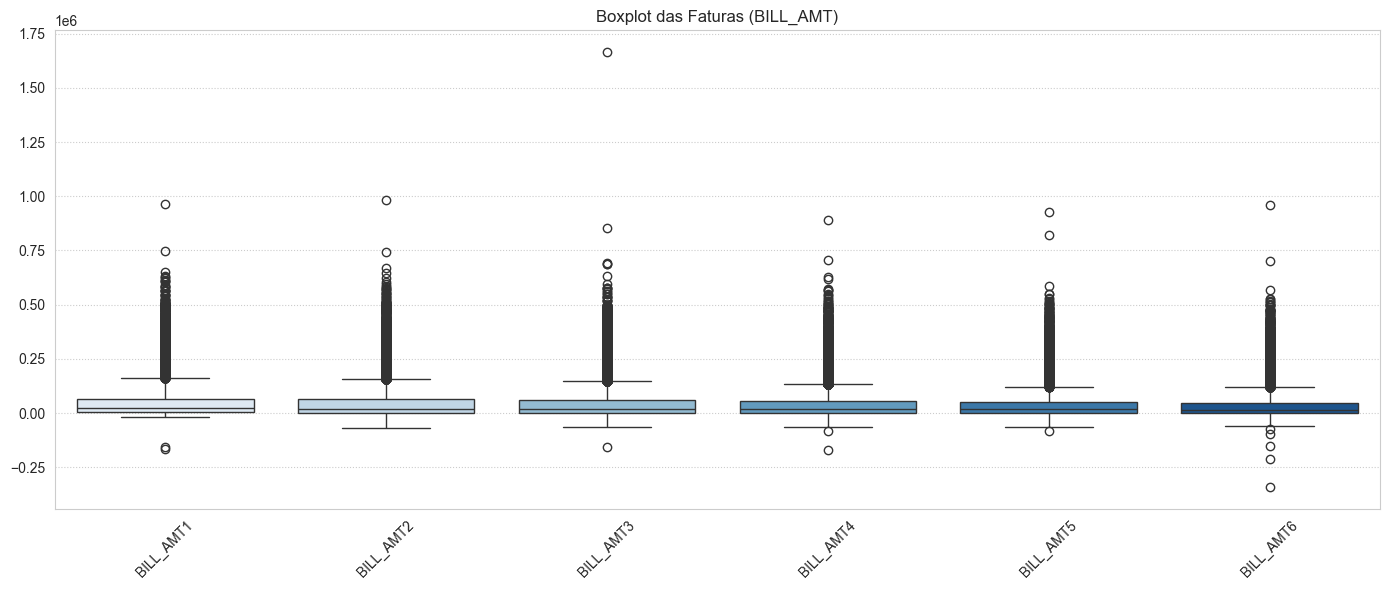

In [151]:
plt.figure(figsize=(14, 6))
# Criando um boxplot para todas as faturas lado a lado
sns.boxplot(data=df[colunas_bill_amt], palette="Blues")
plt.title("Boxplot das Faturas (BILL_AMT)")
plt.xticks(rotation=45)
plt.tight_layout()

A média das faturas cresceu de 38.871,76 em Abril(BILL_AMT6) para 51.223,33 (BILL_AMT1) em Setembro, ou seja, do semestre. Isso indica que o volume de dívida acumulada está aumentando, consecutivamente, mais endividamento evidenciado.

Assimetria positiva considerada forte, pois, em todos os meses, a média é significativamente maior que a mediana. Isso comprova que uma minoria de clientes possui faturas altíssimas (os "*outliers*" vistos no gráfico), o que "puxa" a média para cima. Sobre os outliers por meio do boxplot evidencia-se que temos clientes com alto nível de gasto em crédito, e por se tratar de crédito esses poucos clientes serão considerados reais e continuarão na análise.

Outra observação importante é que em Abril(BILL_AMT6), temos valores negativos como mostrado na estatística descritiva (-339.603,00), ou seja, temos clientes que possuem créditos significativos, provavelmente devido a estorno, etc...

Conforme vimos acima, possuímos valores negativos, que neste caso, se mostram convenientes, pois, existem clientes que estão com créditos significativos dado a circunstâncias como estorno, etc... Para visualizar mais evidentemente o aumento dos clientes endividados ao decorrer dos meses sem descartar os clientes que possuem créditos do boxplot, vou utilizar a escala logarítmica para tornar a visualização mais simétrica/normalizada, permitindo comparar melhor a mediana e os quartis. Usaremos o parâmetro **'symlog'** que significa logaritmo simétrico e permite valores positivos e negativos.

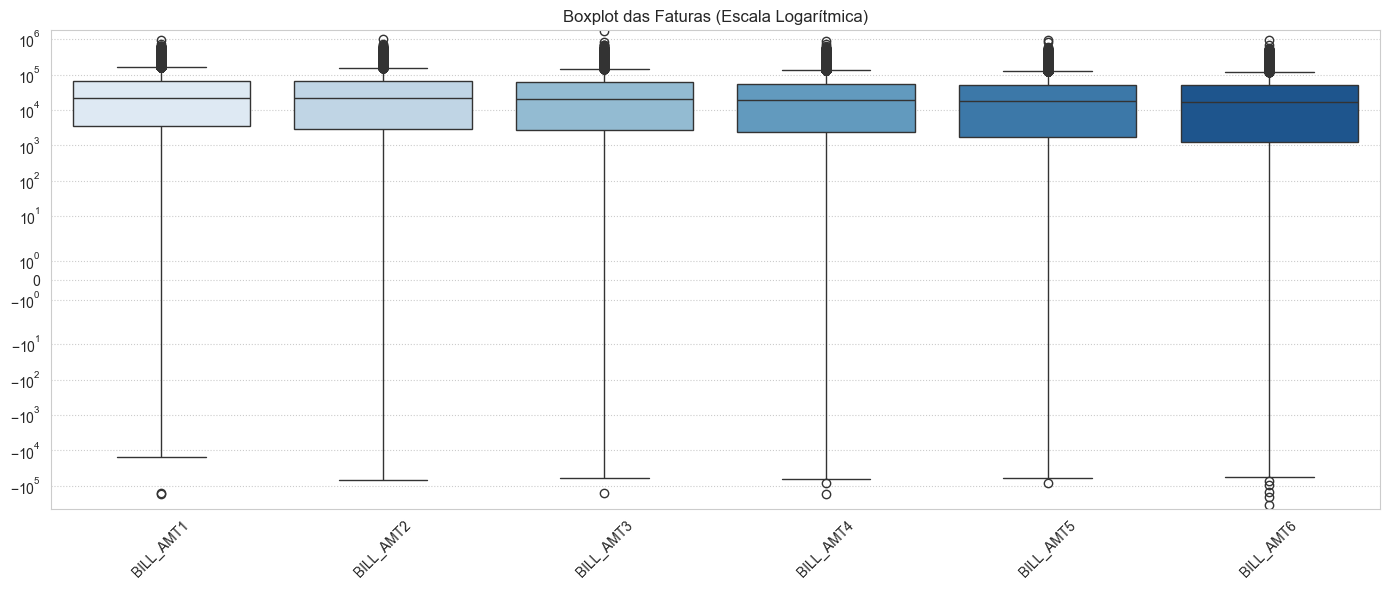

In [152]:
plt.figure(figsize=(14, 6))
# Usando symlog para lidar com os valores negativos que aparecem no gráfico
ax = sns.boxplot(data=df[colunas_bill_amt], palette="Blues")
ax.set_yscale('symlog') 

plt.title("Boxplot das Faturas (Escala Logarítmica)")
plt.xticks(rotation=45)
plt.tight_layout()

Para visualizarmos ainda mais de perto o leve aumento das faturas, usarei outro parâmetro da escala logarítmica que é o parâmentro **Log**. Essa transformação facilita observar medianas, intervalos interquartis e outliers.

A partir do gráfico, nota-se que os valores das faturas permanecem relativamente estáveis entre os meses, embora haja **uma leve elevação no mês mais recente** Setembro(BILL_AMT1), indicando um pequeno aumento nos valores das faturas em relação aos meses anteriores.

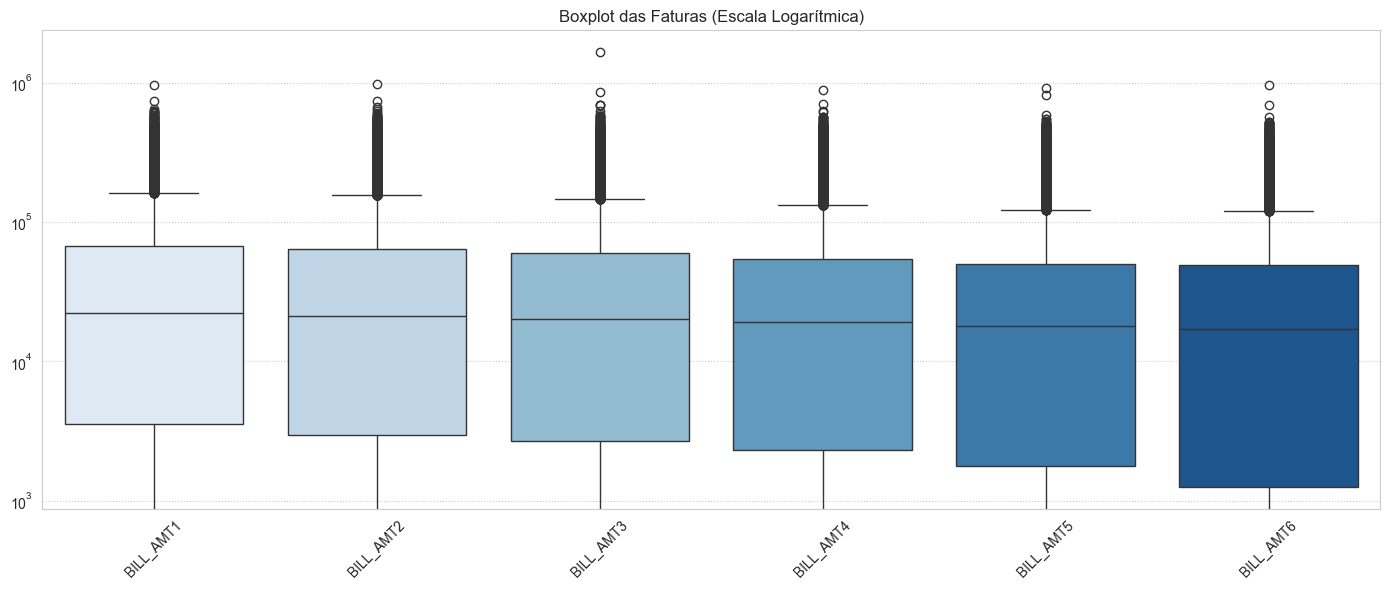

In [153]:
plt.figure(figsize=(14, 6))
# Usando symlog para lidar com os valores negativos que aparecem no gráfico
ax = sns.boxplot(data=df[colunas_bill_amt], palette="Blues")
ax.set_yscale('log') 

plt.title("Boxplot das Faturas (Escala Logarítmica)")
plt.xticks(rotation=45)
plt.tight_layout()

#### PAY_AMT1 a PAY_AMT6 (**valor pago**)

In [154]:
# Lista de valores pagos dos meses
colunas_pay_amt = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Estatísticas descritivas para as colunas de fatura
estatisticas_pay_amt = df[colunas_pay_amt].describe()
estatisticas_pay_amt

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


Primeiramente observa-se que temos clientes no conjunto de dados que não realizam pagamentos de fatura, isso deve-se ao valor de **0**, portanto, esses clientes podem estar com um alto risco de atraso, consecutivamente inadimplência.

Comparando a média de fatura que vimos na variável **BILL_AMT** acima, 25% a 50% dos clientes realizam pagamentos "baixos e mínimos", exemplo: Abril(PAY_AMT6) **11,17(25%)** e **1500(50%)**. Então, a faixa de endividamento tende a crescer casa vez mais, devido a clientes que estão em uma **situação "crítica"** que mal conseguem realizar pagamentos "simbólicos".

Em suma, os valores que vimos na estatística descritiva é altamente alarmante para forte inadimplência de crédito.

#### Inadimplência Próximo Mês (default payment next month)

Nos dados fornecidos esta variável trata-se de uma variável binária, portanto, por escolha deixarei presente nas variáveis numéricas.

1 = Inadimplente, 0 = Não Inadimplente

In [155]:
# Frequência Absoluta E Percentual
freq_absoluta = df['default payment next month'].value_counts()
freq_percentual = df['default payment next month'].value_counts(normalize=True) * 100

# Criando DataFrame com resultados
tabela_frequencia = pd.DataFrame({
    'Frequência Absoluta': freq_absoluta,
    'Frequência Percentual (%)': freq_percentual.round(2)
}).sort_index()

print("TABELA DE FREQUÊNCIA VARIÁVEL default payment next month:")
print("=" * 50)
print(tabela_frequencia)

TABELA DE FREQUÊNCIA VARIÁVEL default payment next month:
                            Frequência Absoluta  Frequência Percentual (%)
default payment next month                                                
0                                         23364                      77.88
1                                          6636                      22.12


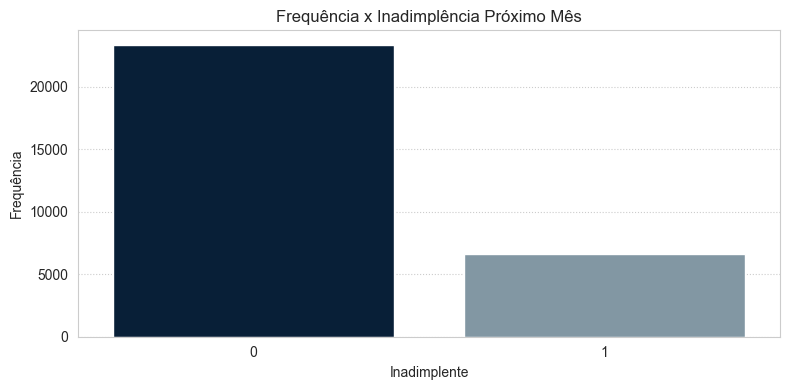

In [156]:
fig, ax = plt.subplots(figsize = (8,4))
# Definindo a paleta de cores
colors = ["#001F3F", "#7D99A8"]
sns.set_palette(sns.color_palette(colors))
count = df["default payment next month"].value_counts
sns.countplot(x='default payment next month', data=df, hue='default payment next month', palette=colors, legend=False)
ax.set_xlabel("Inadimplente")
ax.set_ylabel("Frequência")
ax.set_title("Frequência x Inadimplência Próximo Mês")
plt.tight_layout()

Observando a frequência da variável *Inadimplência no mês seguinte*, nítidamente no conjunto de dados temos 23364(**77,88%**) de clientes que não correm risco de serem indimplentes no mês seguinte, contra 6636(**22,12%**) que tem um risco enorme, portanto, por se tratar de risco de crédito, percebe-se que é uma diferença bem expressiva e altamante alarmante para a empresa.

## (EDA) Análise Bivariada Focada na Variável Default(Inadimplência) e Teste de Hipótese

Para respondermos o **objetivo** do projeto que é:

**Clientes com histórico de atraso superior a 2 meses apresentam risco significativamente maior de inadimplência?**

Irei criar a variável "max_delay" no conjunto de dados que tem por finalidade revelar o maior atraso de pagamento registrado por cliente nos últimos 6 meses, isso irá permitir a análise da relação entre atraso de pagamento(max_delay) e inadiplêmcia(default).

In [157]:
df["max_delay"] = df[colunas_pay].max(axis=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARITAL_STATUS,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,max_delay
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,689,0,0,0,0,1,2
1,2,120000,2,2,2,26,-1,2,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,2
2,3,90000,2,2,2,34,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,0
3,4,50000,2,2,1,37,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,19146,19131,2000,36681,10000,9000,689,679,0,0


Com a variável "max_delay" criada, vamos checar a média de taxa de Inadimplência por nível de atraso de pagamento, isso irá nos ajudar a enxergar se houve um salto considerável no atraso após 2 meses, fortalecendo ainda mais risco de crédito.

### Taxa média de inadimplência(default) x Maior atraso de pagamento

Conforme aprendemos no dicionário de dados, os valores negativos não representam risco de crédito, portanto irei fazer uma tratativa para apenas deixar os valores de interesse nas visualizações que serão criadas.

In [158]:
# o método .clip() "corta" valores que estão abaixo ou acima de um limite definido, neste caso, lower=0 retirou os valores negativos.

df["max_delay_clean"] = df["max_delay"].clip(lower=0)

In [159]:
taxa_max_delay = df.groupby("max_delay_clean")["default payment next month"].mean() * 100
taxa_max_delay.round(2)

max_delay_clean
0    11.71
1    24.99
2    43.55
3    62.23
4    64.22
5    50.72
6    56.00
7    83.58
8    56.00
Name: default payment next month, dtype: float64

Para compreendermos o resultado acima, criarei dois gráficos, o primeiro será uma curva de risco para visualizarmos o salto que ocorreu e também será criado um gráfico de barras para melhor dimensionalizar as taxas no contexto.

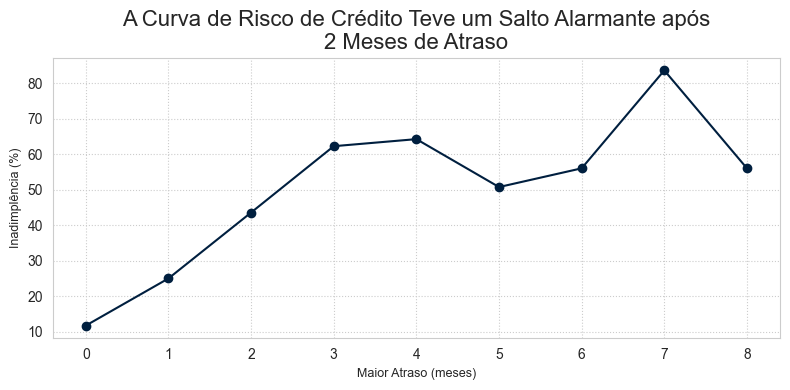

In [160]:
# Gráfico Curva de Risco

plt.subplots(figsize=(8, 4))
plt.plot(taxa_max_delay.index, taxa_max_delay.values, marker='o')
plt.title("A Curva de Risco de Crédito Teve um Salto Alarmante após\n2 Meses de Atraso", fontsize=16)
plt.xlabel("Maior Atraso (meses)", fontsize=9)
plt.ylabel("Inadimplência (%)", fontsize=9)
plt.gca().set_facecolor("white")
plt.tight_layout()

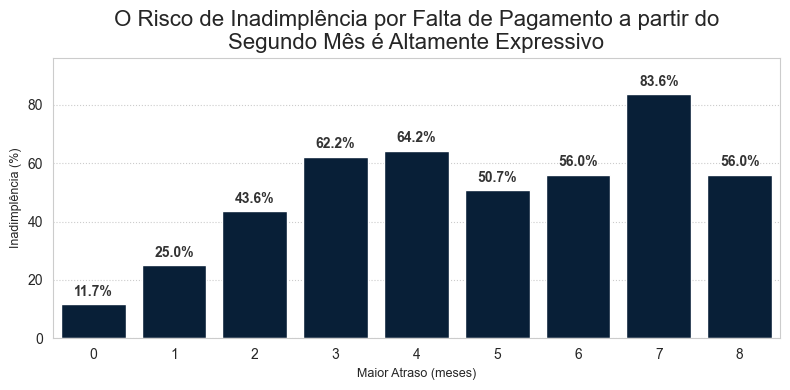

In [161]:
# Gráfico de Barras
fig, ax = plt.subplots(figsize=(8, 4))

# Definindo as cores (Azul Marinho e Cinza Azulado)
colors = ["#001F3F"]

# Criando o gráfico
# O x será o índice (os grupos) e o y os valores da taxa
plot = sns.barplot(
    x=taxa_max_delay.index, 
    y=taxa_max_delay.values, 
    hue=taxa_max_delay.index,
    palette=sns.color_palette(colors, n_colors=len(taxa_max_delay)),
    legend=False
)

# Adicionando as porcentagens acima das barras
for p in plot.patches:
    height = p.get_height()
    plot.annotate(
        f'{height:.1f}%', 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=10, fontweight='bold', color='#333333'
    )

# Ajustes de títulos e eixos
ax.set_title("O Risco de Inadimplência por Falta de Pagamento a partir do\nSegundo Mês é Altamente Expressivo", fontsize=16)
ax.set_xlabel("Maior Atraso (meses)", fontsize=9)
ax.set_ylabel("Inadimplência (%)", fontsize=9)

# Ajuste do limite do eixo Y para os números não cortarem
ax.set_ylim(0, taxa_max_delay.max() * 1.15)
plt.tight_layout()

Nítidamente visualizamos nos gráficos que a partir do 2 mês em diante o risco de inadimplência aumenta significamente, assim que o cliente entra em atraso de 1 mês, a chance de ele não pagar no mês seguinte já pula para 25%. Com 2 meses, sobe para 43.6%.

A partir do 3 mês o risco sobe para 62,2% por mais que caiu no mês 5 e 6, ainda assim é considerado um risco crítico de atraso que com toda certeza contribui para o salto a priori de inadimplentes.

Para que possamos realizar o teste de hipótese em breve que validará estatísticamente a hipótese acima, irei criar dois grupos de atraso (<=2 meses vs >2 meses)

### Taxa média de inadimplência(default) x Grupos de atraso

In [162]:
# Criando variável categórica para divisão estratégica

df["grupo_atraso"] = df["max_delay"].apply(lambda x: "<=2 meses" if x <= 2 else ">2 meses")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARITAL_STATUS,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,max_delay,max_delay_clean,grupo_atraso
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,689,0,0,0,0,1,2,2,<=2 meses
1,2,120000,2,2,2,26,-1,2,0,0,...,0,1000,1000,1000,0,2000,1,2,2,<=2 meses
2,3,90000,2,2,2,34,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,0,0,<=2 meses
3,4,50000,2,2,1,37,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,0,0,<=2 meses
4,5,50000,1,2,1,57,-1,0,-1,0,...,2000,36681,10000,9000,689,679,0,0,0,<=2 meses


In [163]:
# Verificando distribuição dos grupos

df["grupo_atraso"].value_counts()

grupo_atraso
<=2 meses    28807
>2 meses      1193
Name: count, dtype: int64

Por meio da distribuição podemos definir esses dois grupos considerados como:
- controlável (<=2 meses com 28807 clientes).
- risco (>2 meses com 1193 clientes).

In [164]:
# Calculando taxa média de default por grupo

taxa_default = df.groupby("grupo_atraso")["default payment next month"].mean()

# Convertendo para percentual

taxa_default_percentual = (taxa_default * 100).round(2)
taxa_default_percentual

grupo_atraso
<=2 meses    20.43
>2 meses     62.87
Name: default payment next month, dtype: float64

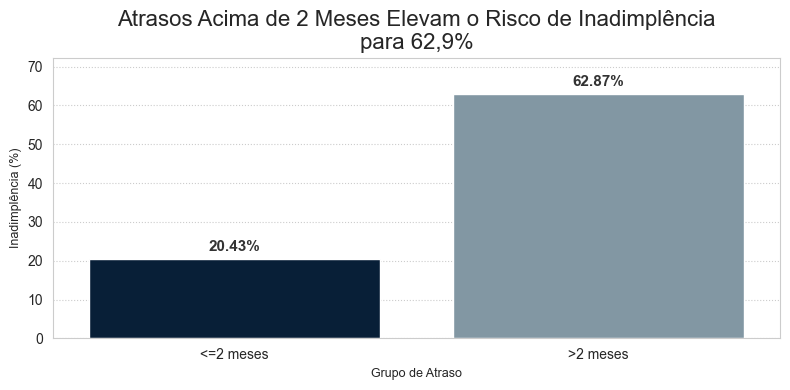

In [165]:
# Configurando a figura e o estilo conforme seu padrão
fig, ax = plt.subplots(figsize=(8, 4))

# Definindo a paleta de cores
colors = ["#001F3F", "#7D99A8"]

# Criando o gráfico de barras
plot = sns.barplot(
    x=taxa_default_percentual.index, 
    y=taxa_default_percentual.values, 
    hue=taxa_default_percentual.index, 
    palette=colors, 
    legend=False
)

# --- ADICIONANDO AS PORCENTAGENS ACIMA DAS BARRAS ---
for p in plot.patches:
    plot.annotate(
        format(p.get_height(), '.2f') + '%', # Formata com 2 casas decimais e o símbolo %
        (p.get_x() + p.get_width() / 2., p.get_height()), # Posiciona no centro da barra (x) e no topo (y)
        ha='center', va='center', 
        xytext=(0, 9), # Desloca o texto 9 pontos para cima para não grudar na barra
        textcoords='offset points',
        fontsize=11, fontweight='bold', color='#333333' # Estilização do texto
    )

# Ajustando os eixos e título
ax.set_xlabel("Grupo de Atraso", fontsize=9)
ax.set_ylabel("Inadimplência (%)", fontsize=9)
ax.set_title("Atrasos Acima de 2 Meses Elevam o Risco de Inadimplência\npara 62,9%", fontsize=16)

# Definindo um limite um pouco maior no eixo Y para o número não cortar no topo
ax.set_ylim(0, taxa_default_percentual.max() * 1.15)

plt.tight_layout()

A taxa média de clientes inadimplentes nos grupos são:

**<=2 meses** = 20.43%

**>2 meses** = 62,87%

De forma transparente temos uma diferença de **42,44** pontos percentuais do grupo considerado "controlável" para o de "risco". Vamos validar se esse insight é estatísticamente significativo para um todo, por meio do teste de hipótese.

### Teste de Hipótese

Como os tamanhos amostrais são superiores a 30 observações em cada grupo, conforme vimos acima, o Teorema do Limite Central é aceito, ou seja, a distribuição dos dados se aproxima de uma normal.

Iremos usar o **Teste Z** para proporção para duas amostras independentes.
- Isto é, esse teste permite avaliar se a diferença observada entre as proporções de inadimplência no próximo mês dos dois grupos é estatísticamente significativa.

- O nível de significância adotado para o teste é 0.05(95%).

Hipóteses:

- HO: Não há diferença na taxa de inadimplência entre clientes com atraso <=2 meses e clientes com atraso >2 meses.

- HA: Clientes com atraso >2 meses apresentam uma taxa de risco maior de inadimplência.

In [166]:
# Separando os dois grupos

df_atraso_menor2 = df[df["grupo_atraso"] == "<=2 meses"]
df_atraso_maior2 = df[df["grupo_atraso"] == ">2 meses"]

In [167]:
# Número de inadimplentes em cada grupo

sucessos = [df_atraso_menor2["default payment next month"].sum(), df_atraso_maior2["default payment next month"].sum()]

# Total de clientes em cada grupo.

nobs = [len(df_atraso_menor2), len(df_atraso_maior2)]

In [168]:
from statsmodels.stats.proportion import proportions_ztest

stat, p_value = proportions_ztest(sucessos, nobs)
print("Teste Z:", stat)
print("P-valor:", p_value)

# Nível de significância
alpha = 0.05
if p_value < alpha:
    print("Rejeitamos H0: clientes com atraso >2 meses possuem maior risco de inadimplência.")
else:
    print("Não há evidência estatística suficiente para afirmar diferença.")

Teste Z: -34.60341667103128
P-valor: 2.244526360427735e-262
Rejeitamos H0: clientes com atraso >2 meses possuem maior risco de inadimplência.


Com um alpha de 0,05 de significância, dado o **valor Extremamente baixo** do p-valor, rejeitamos a hipótese nula e comprovamos que de fato, os clientes com atraso maior que dois meses possuem um risco de inadimplência estatísticamente significativo.

## Conclusão e Recomendações

Em suma, esta análise de risco de crédito, foi direcionada para ser objetiva em torno da hipótese conforme consta no objetivo.

**Resumo da análise**
- Descobrimos que temos clientes que estão em uma **situação "crítica"** que mal conseguem realizar pagamentos "simbólicos".
- Os clientes com histórico de atraso **superior a dois meses** apresentam **risco significativamente maior** de inadimplência no mês seguinte.
- Observou-se uma taxa média de inadimplência de **62,87%** para esse grupo considerado de risco, enquanto clientes com atraso máximo de até dois meses apresentam taxa de **20,43%**, representando uma diferença de aproximadamente **42,44** pontos percentuais.

**Confirmação estatística da hipótese**
- O teste estatístico de diferença de proporções resultou em um p-valor extremamente baixo (p < 0.05), indicando que a diferença observada entre os grupos não é fruto do acaso. Dessa forma, rejeitamos a hipótese nula e concluímos que clientes com histórico de atraso superior a dois meses possuem probabilidade significativamente maior de inadimplência no mês seguinte.

**Área de negócio**
- Esse resultado sugere que o histórico de atraso é um indicador relevante para avaliação de risco de crédito. Clientes que apresentaram atrasos superiores a dois meses demonstram comportamento significativamente mais arriscado, podendo exigir maior cautela em políticas de concessão de crédito.

**Recomendações**
- Estratégias como políticas de crédito mais restritivas para diminuir o risco de inadimplência.
- Monitoramento preventivo e segmentação de risco podem auxiliar na mitigação de perdas associadas à inadimplência.